In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 4*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [13]:
df = pd.DataFrame()

In [17]:
df['X'] = X.reshape(100)
df['y'] = y

In [18]:
df

,X,y
0,-0.125460,0.067313
1,0.450714,0.797623
2,0.231994,0.219873
3,0.098658,-0.060444
4,-0.343981,0.462309
...,...,...
95,-0.006204,-0.040637
96,0.022733,-0.001788
97,-0.072459,0.038059
98,-0.474581,0.914743


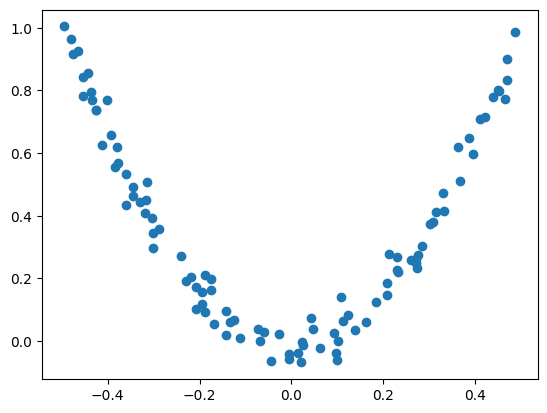

In [19]:
plt.scatter(df['X'], df['y'])

In [20]:
df['pred1'] = df['y'].mean()

In [21]:
df

,X,y,pred1
0,-0.125460,0.067313,0.353963
1,0.450714,0.797623,0.353963
2,0.231994,0.219873,0.353963
3,0.098658,-0.060444,0.353963
4,-0.343981,0.462309,0.353963
...,...,...,...
95,-0.006204,-0.040637,0.353963
96,0.022733,-0.001788,0.353963
97,-0.072459,0.038059,0.353963
98,-0.474581,0.914743,0.353963


In [22]:
df['res1'] = df['y'] - df['pred1']

In [23]:
df

,X,y,pred1,res1
0,-0.125460,0.067313,0.353963,-0.286649
1,0.450714,0.797623,0.353963,0.443661
2,0.231994,0.219873,0.353963,-0.134090
3,0.098658,-0.060444,0.353963,-0.414407
4,-0.343981,0.462309,0.353963,0.108347
...,...,...,...,...
95,-0.006204,-0.040637,0.353963,-0.394599
96,0.022733,-0.001788,0.353963,-0.355750
97,-0.072459,0.038059,0.353963,-0.315904
98,-0.474581,0.914743,0.353963,0.560780


In [24]:
from sklearn.tree import DecisionTreeRegressor

In [25]:
tree_1 = DecisionTreeRegressor(max_leaf_nodes = 8)
tree_1.fit(df['X'].values.reshape(100, 1), df['res1'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

<function matplotlib.pyplot.show(close=None, block=None)>

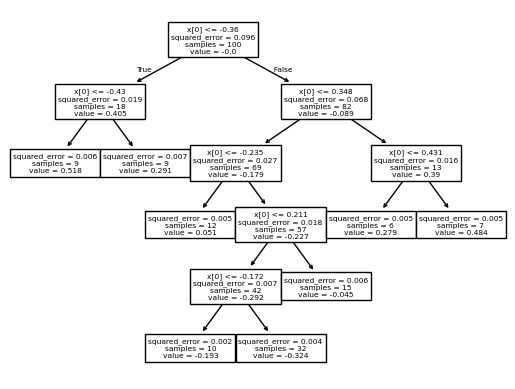

In [27]:
from sklearn.tree import plot_tree
plot_tree(tree_1)
plt.show

In [29]:
X_test = np.linspace(-0.5, 0.5, 500)
y_pred = 0.353963 + tree_1.predict(X_test.reshape(500, 1))

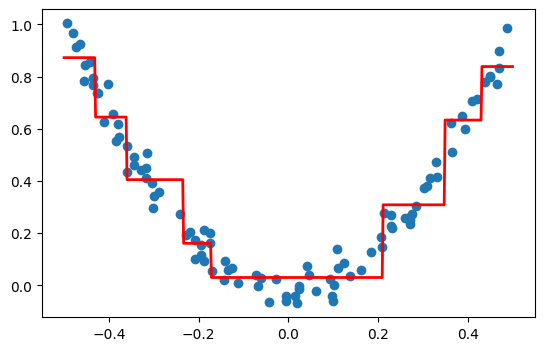

In [32]:
plt.figure(figsize = (14, 4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth = 2, color = 'red')
plt.scatter(df['X'], df['y'])

In [35]:
df['pred2'] = 0.353963 + tree_1.predict(df['X'].values.reshape(100, 1))
df

,X,y,pred1,res1,pred2
0,-0.125460,0.067313,0.353963,-0.286649,0.030307
1,0.450714,0.797623,0.353963,0.443661,0.838338
2,0.231994,0.219873,0.353963,-0.134090,0.308687
3,0.098658,-0.060444,0.353963,-0.414407,0.030307
4,-0.343981,0.462309,0.353963,0.108347,0.405071
...,...,...,...,...,...
95,-0.006204,-0.040637,0.353963,-0.394599,0.030307
96,0.022733,-0.001788,0.353963,-0.355750,0.030307
97,-0.072459,0.038059,0.353963,-0.315904,0.030307
98,-0.474581,0.914743,0.353963,0.560780,0.872451


In [36]:
df['res2'] = df['y'] - df['pred2']
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.067313,0.353963,-0.286649,0.030307,0.037006
1,0.450714,0.797623,0.353963,0.443661,0.838338,-0.040715
2,0.231994,0.219873,0.353963,-0.134090,0.308687,-0.088814
3,0.098658,-0.060444,0.353963,-0.414407,0.030307,-0.090751
4,-0.343981,0.462309,0.353963,0.108347,0.405071,0.057238
...,...,...,...,...,...,...
95,-0.006204,-0.040637,0.353963,-0.394599,0.030307,-0.070944
96,0.022733,-0.001788,0.353963,-0.355750,0.030307,-0.032095
97,-0.072459,0.038059,0.353963,-0.315904,0.030307,0.007752
98,-0.474581,0.914743,0.353963,0.560780,0.872451,0.042291


In [37]:
tree_2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree_2.fit(df['X'].values.reshape(100, 1),df['res2'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [38]:
y_pred = 0.353963 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree_1, tree_2])

Text(0.5, 1.0, 'X vs y')

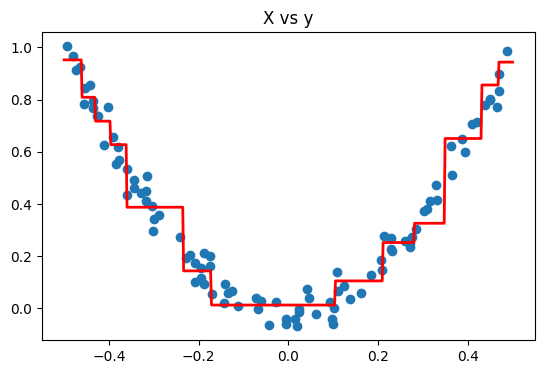

In [39]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])
plt.title('X vs y')

In [45]:
def GB(X, y, num, lr, count = 1, regs = [], foo = None):
    if num == 0:
        return
    else:
        if count > 1:
            y = y - regs[-1].predict(X)
        else:
            foo = y

        tree_reg = DecisionTreeRegressor(max_depth = 5, random_state = 42)
        tree_reg.fit(X, y)
        regs.append(tree_reg)
        x1 = np.linspace(-0.5, 0.5, 500)
        y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

        print(num)
        plt.figure()
        plt.plot(x1, y_pred, linewidth = 2)
        plt.plot(X[:, 0], foo, "r")
        plt.show()

        GB(X, y, num-1, lr, count+1, regs, foo = foo)

5


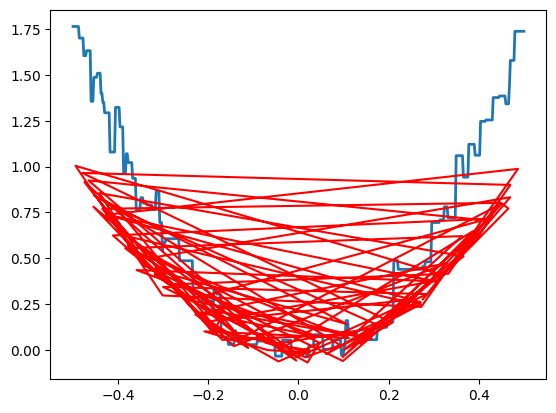

4


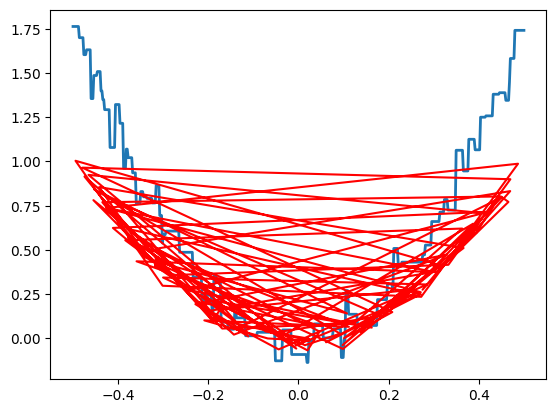

3


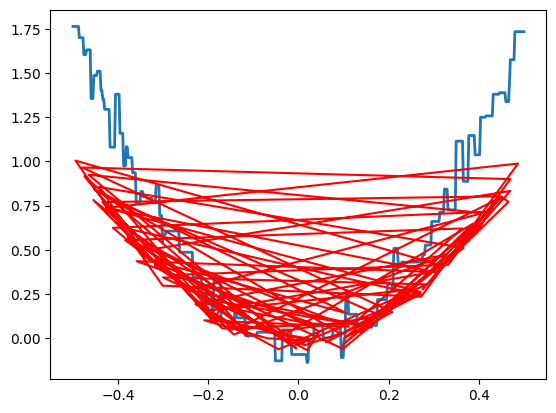

2


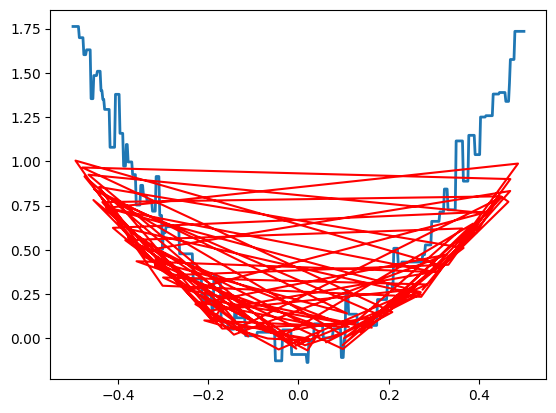

1


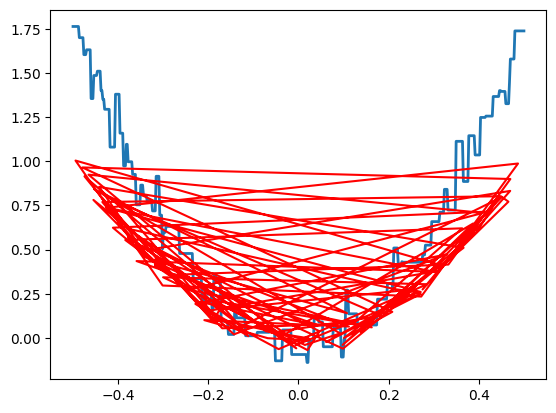

In [47]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 4*X[:, 0]**2 + 0.05 * np.random.randn(100)
GB(X,y,5,lr=1)